In [1]:
import os
import numpy as np
import pandas as pd
import nltk
import yake
import torch
import networkx as nx
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from joblib import Parallel, delayed
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from gensim.models import Doc2Vec
from gensim.models.doc2vec import TaggedDocument
from sklearn.feature_extraction.text import TfidfVectorizer
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    average_precision_score,
)
from sklearn.metrics.pairwise import cosine_similarity
from scipy.linalg import fractional_matrix_power
from torch_geometric.data import HeteroData
from torch_geometric.nn import HeteroConv, GATConv

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)

True

In [2]:

STOP_WORDS = set(stopwords.words("english"))


In [3]:
df = pd.read_csv("data/evaluation.csv", on_bad_lines="skip", delimiter=";")

In [4]:
df.columns

Index(['Unnamed: 0', 'title', 'text', 'label'], dtype='object')

In [5]:
df.dropna(inplace=True)
df["title"] = df["title"].str.cat(df["text"], sep=" ")

df.rename(columns={"title": "full_text"}, inplace=True)

df["binary_label"] = np.where(df["label"].isin(["fake", "1", 1]), 1, 0)
df.drop(columns=["label", "text", "Unnamed: 0"], inplace=True)

df.reset_index(drop=True, inplace=True)

In [6]:
def preprocess(input: str):

    if not isinstance(input, str):
        return ""
    input = input.lower() 
    
    input = input.translate(str.maketrans('', '', string.punctuation)) 

    t = word_tokenize(input) 
    t = [w for w in t if w not in STOP_WORDS]  
    l = WordNetLemmatizer()
    return ' '.join([l.lemmatize(w) for w in t])

In [7]:
parallel = Parallel(n_jobs=os.cpu_count(), backend="loky")
df["full_text"] = parallel(delayed(preprocess)(input) for input in df["full_text"])

In [8]:

df.to_csv("data/processed_eval.csv", index=False)

In [9]:
def evaluation_metrics(
    y_true, y_pred, y_proba=None, title=None, labels=["real", "fake"]
):
    print(f"\n{title}")
    print(classification_report(y_true, y_pred, target_names=labels, digits=4))
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot()
    plt.title(title)
    plt.show()
    if y_proba is not None:
        roc_auc = roc_auc_score(y_true, y_proba)
        pr_auc = average_precision_score(y_true, y_proba)
        print(f"ROC-AUC: {roc_auc:.4f}")
        print(f"PR-AUC: {pr_auc:.4f}")
    print("\n")



class KAFNData:
    def __init__(
        self,
        csv_path,
        random_state=42,
        fraction_fake_labeled=0.3,
        test_size=0.2,
    ):
        self.fraction_fake_labeled = fraction_fake_labeled
        df = pd.read_csv(csv_path, on_bad_lines="skip")

        train_df, test_df = train_test_split(
            df,
            test_size=test_size,
            stratify=df["binary_label"],
            random_state=random_state,
        )
        self.df_all = pd.concat([train_df, test_df], ignore_index=True)
        self.df_all["split"] = "test"
        self.df_all.loc[self.df_all.index[: len(train_df)], "split"] = "train"
        self.num_docs = len(self.df_all)

        self.df_all["pu_label"] = -1

        train_fake_inds = self.df_all.index[
            (self.df_all["split"] == "train") & (self.df_all["binary_label"] == 1)
        ].tolist()
        n_label = int(fraction_fake_labeled * len(train_fake_inds))
        if n_label < 1 and len(train_fake_inds) > 0:
            n_label = 1
        if len(train_fake_inds) > 0:
            labeled_inds = np.random.choice(
                train_fake_inds, size=n_label, replace=False
            )
            self.df_all.loc[labeled_inds, "pu_label"] = 1

    def get_doc_text(self, idx):
        return self.df_all.iloc[idx]["full_text"]

    def get_pu_label(self, idx):
        return self.df_all.iloc[idx]["pu_label"]

    def get_binary_label(self, idx):
        return self.df_all.iloc[idx]["binary_label"]

    def is_train_doc(self, idx):
        return self.df_all.iloc[idx]["split"] == "train"

    def is_test_doc(self, idx):
        return self.df_all.iloc[idx]["split"] == "test"


def baseline(data: KAFNData):

    train_df = data.df_all[data.df_all["split"] == "train"]
    X_tr = train_df["full_text"]
    y_tr = train_df["pu_label"].apply(lambda x: 1 if x == 1 else 0)

    test_df = data.df_all[data.df_all["split"] == "test"]
    X_tst = test_df["full_text"]
    y_tst = test_df["binary_label"]

    pipeline = Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    stop_words="english",
                    max_features=5000, 
                    ngram_range=(1, 2), 
                ),
            ),
            (
                "classifier",
                MultinomialNB(
                    class_prior=[0.5, 0.5]
                ), 
            ),
        ]
    )
    pipeline.fit(X_tr, y_tr)
    y_pr = pipeline.predict(X_tst)

    proba = pipeline.predict_proba(X_tst)
    y_proba = proba[:, 1] if proba.shape[1] > 1 else proba[:, 0]

    title = f"=== Baseline with TfidfVectorizer and MultinomialNB, Labeled fraction {data.fraction_fake_labeled} ==="
    evaluation_metrics(y_tst, y_pr, y_proba, title=title)



class Doc2VecEmb:
    def __init__(self, vector_size=100, window=5, min_count=2, epochs=20, workers=4):

        self.model = None
        self.vsize = vector_size
        self.window = window
        self.min_count = min_count
        self.epochs = epochs
        self.workers = workers

    def train(self, data: KAFNData):
        docs = []
        for i in range(data.num_docs):
            tokens = word_tokenize(data.get_doc_text(i).lower())
            docs.append(TaggedDocument(tokens, [i]))

        model = Doc2Vec(
            documents=docs,
            vector_size=self.vsize,
            window=self.window,
            min_count=self.min_count,
            epochs=self.epochs,
            workers=self.workers,
        )
        self.model = model

    def get_vector(self, i):
        return self.model.dv[i]


class TFIDFEmb:

    def __init__(
        self, max_features=10000, ngram_range=(1, 1), min_df=1, stop_words="english"
    ):
        self.vectorizer = TfidfVectorizer(
            max_features=max_features,
            ngram_range=ngram_range,
            min_df=min_df,
            stop_words=stop_words,
        )
        self.doc_vectors = None 

    def train(self, data):
        texts = [data.get_doc_text(i) for i in range(data.num_docs)]
        tfidf_matrix = self.vectorizer.fit_transform(
            texts
        )  
        self.doc_vectors = tfidf_matrix.toarray()

    def get_vector(self, i):
        return self.doc_vectors[i]


def build_doc_graph(data: KAFNData, emb_model: Doc2VecEmb, k=5):
    N = data.num_docs
    all_emb = np.array([emb_model.get_vector(i) for i in range(N)])
    sim = cosine_similarity(all_emb)

    G = nx.Graph()
    for i in range(N):
        G.add_node(i, node_type="doc")

    for i in range(N):
        row = sim[i].copy()
        row[i] = -999 
        nbrs = np.argsort(row)[::-1][:k]
        for n in nbrs:
            G.add_edge(i, n, weight=sim[i, n])
            G.add_edge(n, i, weight=sim[i, n])

    for i in range(N):
        neighbors = list(G.neighbors(i))
        total_w = sum(G[i][nb]["weight"] for nb in neighbors)
        if total_w > 0:
            for nb in neighbors:
                old_w = G[i][nb]["weight"]
                G[i][nb]["weight"] = old_w / total_w
    return G



def compute_katz_matrix(G, alpha=0.01):
    nodes = sorted(G.nodes())
    N = len(nodes)
    A = np.zeros((N, N), dtype=float)
    idx_map = {n: i for i, n in enumerate(nodes)}
    for u, v, data_e in G.edges(data=True):
        A[idx_map[u], idx_map[v]] = data_e["weight"]

    I = np.eye(N)
    try:
        mat = fractional_matrix_power(I - alpha * A, -1) - I
        return mat, idx_map
    except np.linalg.LinAlgError:
        print("Katz inversion failed.")
        return None, idx_map


def iterative_pu_lp(katz_mat, idx_map, pos_indices, unl_indices, m_iter=3, lam=1.0):

    pos_set = set(pos_indices)
    unl_set = set(unl_indices)

    R_I_tot = set()
    R_N_tot = set()

    def mean_sim(u_id, pos_ids):
        if not pos_ids:
            return 0.0
        row_u = idx_map[u_id]
        sims = [katz_mat[row_u, idx_map[p_id]] for p_id in pos_ids]
        return np.mean(sims) if len(sims) > 0 else 0.0

    for _ in range(m_iter):
        subset_size = int((lam / m_iter) * len(pos_set))
        if subset_size < 1 and len(pos_set) > 0:
            subset_size = 1
        unl_scores = [(u, mean_sim(u, pos_set)) for u in unl_set]
        unl_scores.sort(key=lambda x: x[1], reverse=True)
        R_I_prime = [x[0] for x in unl_scores[:subset_size]]
        for r in R_I_prime:
            unl_set.remove(r)
        R_I_tot.update(R_I_prime)
        pos_set.update(R_I_prime)
        unl_scores2 = [(u, mean_sim(u, pos_set)) for u in unl_set]
        unl_scores2.sort(key=lambda x: x[1])
        R_N_prime = [x[0] for x in unl_scores2[:subset_size]]
        for r in R_N_prime:
            unl_set.remove(r)
        R_N_tot.update(R_N_prime)

    return list(R_I_tot), list(R_N_tot), list(unl_set)

def extract_yake_keywords(text, top_k, yake_lan, yake_n, yake_dedup_lim):
    extractor = yake.KeywordExtractor(lan=yake_lan, n=yake_n, dedupLim=yake_dedup_lim)
    kw = extractor.extract_keywords(text)
    kw.sort(key=lambda x: x[1])  
    return kw[:top_k]


def build_doc_term_edges(
    G_doc,
    data: KAFNData,
    top_k=5,
    yake_lan="en",
    yake_n=1,
    yake_dedup_lim=0.9,
    n_jobs=32,
):
    N = data.num_docs
    H = nx.Graph()

    for i in range(N):
        H.add_node(i, node_type="doc")

    for u, v, d in G_doc.edges(data=True):
        H.add_edge(u, v, weight=d["weight"])

    all_texts = [data.get_doc_text(i) for i in range(N)]
    parallel = Parallel(
        n_jobs=n_jobs, backend="loky"
    ) 

    all_kw_lists = parallel(
        delayed(extract_yake_keywords)(text, top_k, yake_lan, yake_n, yake_dedup_lim)
        for text in all_texts
    )

    term_usage = {}
    raw_doc_terms = [[] for _ in range(N)]
    for i, kw in enumerate(all_kw_lists):
        for ts, sc in kw:
            raw_doc_terms[i].append((ts, sc))
            term_usage.setdefault(ts, set()).add(i)
    valid_terms = {t for t, used_by in term_usage.items() if len(used_by) >= 2}
    next_id = N
    term_map = {}
    for t in valid_terms:
        term_map[t] = next_id
        H.add_node(next_id, node_type="term")
        next_id += 1

    for i in range(N):
        doc_term_list = []
        for ts, sc in raw_doc_terms[i]:
            if ts not in valid_terms:
                continue
            if sc > 1:
                w_val = 0.0
            else:
                w_val = sc * (1 - (1 / (1 + sc)))
            if w_val > 0:
                doc_term_list.append((ts, w_val))

        denom = sum(x[1] for x in doc_term_list)
        if denom > 0:
            for ts, w in doc_term_list:
                norm_w = w / denom
                tid = term_map[ts]
                H.add_edge(i, tid, weight=norm_w)
                H.add_edge(tid, i, weight=norm_w)

    for node in H.nodes():
        node_type = H.nodes[node]["node_type"]
        neighbors = list(H.neighbors(node))
        total_w = sum(H[node][nb]["weight"] for nb in neighbors)
        if total_w > 0:
            for nb in neighbors:
                H[node][nb]["weight"] /= total_w

    return H


def nx_to_heterodata(H, R_I, R_N, pos_indices, embed_dim=100):
    docs, terms = [], []
    for n, dattr in H.nodes(data=True):
        if dattr["node_type"] == "doc":
            docs.append(n)
        else:
            terms.append(n)
    docs.sort()
    terms.sort()

    doc_label_arr = []
    pos_set = set(pos_indices)
    R_I_set = set(R_I)
    R_N_set = set(R_N)
    for d in docs:
        if d in pos_set or d in R_I_set:
            doc_label_arr.append(1)
        elif d in R_N_set:
            doc_label_arr.append(0)
        else:
            doc_label_arr.append(-1)
    doc_label_arr = np.array(doc_label_arr)

    doc_map = {d: i for i, d in enumerate(docs)}
    term_map = {t: i for i, t in enumerate(terms)}
    doc_x = np.zeros((len(docs), embed_dim), dtype=np.float32)
    term_x = np.zeros((len(terms), embed_dim), dtype=np.float32)

    doc_doc_src, doc_doc_dst, doc_doc_attr = [], [], []
    doc_term_src, doc_term_dst, doc_term_attr = [], [], []
    term_doc_src, term_doc_dst, term_doc_attr = [], [], []

    for u, v, edat in H.edges(data=True):
        w = edat["weight"]
        ut = H.nodes[u]["node_type"]
        vt = H.nodes[v]["node_type"]
        if ut == "doc" and vt == "doc":
            doc_doc_src.append(doc_map[u])
            doc_doc_dst.append(doc_map[v])
            doc_doc_attr.append(w)
        elif ut == "doc" and vt == "term":
            doc_term_src.append(doc_map[u])
            doc_term_dst.append(term_map[v])
            doc_term_attr.append(w)
        elif ut == "term" and vt == "doc":
            term_doc_src.append(term_map[u])
            term_doc_dst.append(doc_map[v])
            term_doc_attr.append(w)

    hetero_data = HeteroData()
    hetero_data["doc"].x = torch.FloatTensor(doc_x)
    hetero_data["doc"].labels = torch.LongTensor(doc_label_arr)
    hetero_data["doc"].docs = torch.LongTensor(docs) 

    hetero_data["term"].x = torch.FloatTensor(term_x)

    hetero_data["doc", "to", "doc"].edge_index = torch.tensor(
        [doc_doc_src, doc_doc_dst], dtype=torch.long
    )
    hetero_data["doc", "to", "doc"].edge_attr = torch.FloatTensor(doc_doc_attr)

    hetero_data["doc", "to", "term"].edge_index = torch.tensor(
        [doc_term_src, doc_term_dst], dtype=torch.long
    )
    hetero_data["doc", "to", "term"].edge_attr = torch.FloatTensor(doc_term_attr)

    hetero_data["term", "to", "doc"].edge_index = torch.tensor(
        [term_doc_src, term_doc_dst], dtype=torch.long
    )
    hetero_data["term", "to", "doc"].edge_attr = torch.FloatTensor(term_doc_attr)

    return hetero_data, docs, terms


def fill_doc_embeddings(hetero_data: HeteroData, docs, data: KAFNData, emb_model):
    doc_x_list = []
    for d in docs:
        emb = emb_model.get_vector(d)
        doc_x_list.append(emb)
    doc_x_arr = np.vstack(doc_x_list).astype(np.float32)
    hetero_data["doc"].x = torch.tensor(doc_x_arr)


class HeteroGAT(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_layers=2, num_heads=4, dropout=0.5):
        super().__init__()

        self.num_layers = num_layers
        self.dropout = dropout

        self.conv1 = HeteroConv(
            {
                ("doc", "to", "doc"): GATConv(
                    in_dim,
                    hidden_dim,
                    heads=num_heads,
                    add_self_loops=False,
                    concat=True,
                ),
                ("doc", "to", "term"): GATConv(
                    in_dim,
                    hidden_dim,
                    heads=num_heads,
                    add_self_loops=False,
                    concat=True,
                ),
                ("term", "to", "doc"): GATConv(
                    in_dim,
                    hidden_dim,
                    heads=num_heads,
                    add_self_loops=False,
                    concat=True,
                ),
            },
            aggr="sum",
        )

        self.conv2 = None
        if num_layers >= 2:
            self.conv2 = HeteroConv(
                {
                    ("doc", "to", "doc"): GATConv(
                        hidden_dim * num_heads,
                        hidden_dim,
                        heads=num_heads,
                        add_self_loops=False,
                        concat=True,
                    ),
                    ("doc", "to", "term"): GATConv(
                        hidden_dim * num_heads,
                        hidden_dim,
                        heads=num_heads,
                        add_self_loops=False,
                        concat=True,
                    ),
                    ("term", "to", "doc"): GATConv(
                        hidden_dim * num_heads,
                        hidden_dim,
                        heads=num_heads,
                        add_self_loops=False,
                        concat=True,
                    ),
                },
                aggr="sum",
            )

        final_dim = hidden_dim * num_heads if self.conv2 else hidden_dim * num_heads
        self.classify = nn.Linear(final_dim, 1)

    def forward(self, data: HeteroData):
        x_dict, edge_index_dict, edge_attr_dict = (
            data.x_dict,
            data.edge_index_dict,
            data.edge_attr_dict,
        )

        out1 = self.conv1(x_dict, edge_index_dict, edge_attr_dict)
        for nt in out1:
            out1[nt] = F.elu(out1[nt])
            out1[nt] = F.dropout(out1[nt], p=self.dropout, training=self.training)

        if self.conv2 is not None:
            out2 = self.conv2(out1, edge_index_dict, edge_attr_dict)
            for nt in out2:
                out2[nt] = F.elu(out2[nt])
                out2[nt] = F.dropout(out2[nt], p=self.dropout, training=self.training)
            doc_logits = self.classify(out2["doc"]).squeeze(-1)
            return out2, doc_logits
        else:
            doc_logits = self.classify(out1["doc"]).squeeze(-1)
            return out1, doc_logits

def kafn_pulp_pipeline(
    data: KAFNData,
    embed_dim=100,
    doc2vec_window=5,
    doc2vec_min_count=2,
    doc2vec_epochs=20,
    doc2vec_workers=os.cpu_count(),
    k=5, 
    alpha_katz=0.01,
    m_iter=3, 
    m_factor=1.0, 
    top_yake=5,
    yake_lan="en",
    yake_n=1,
    yake_dedup_lim=0.9,
    n_jobs=os.cpu_count(),
    gat_hidden_dim=64,
    gat_num_layers=2,
    gat_num_heads=4,
    gat_dropout=0.5,
    num_epochs=30,
    lr=1e-3,
    weight_decay=1e-4, 
    device="cpu",
):
    print("=== Training Doc2Vec ===")
    emb_model = Doc2VecEmb(
        vector_size=embed_dim,
        window=doc2vec_window,
        min_count=doc2vec_min_count,
        epochs=doc2vec_epochs,
        workers=doc2vec_workers,
    )
    emb_model.train(data)

    print("=== Building doc-doc graph ===")
    G_doc = build_doc_graph(data, emb_model, k=k)

    print("=== Computing Katz matrix ===")
    katz_mat, idx_map = compute_katz_matrix(G_doc, alpha=alpha_katz)
    if katz_mat is None:
        print("Katz failed, aborting.")
        return
    pos_indices = [i for i in range(data.num_docs) if data.get_pu_label(i) == 1]
    unl_indices = [i for i in range(data.num_docs) if data.get_pu_label(i) == -1]

    print("=== Iterative PU Label Propagation ===")
    R_I, R_N, leftover = iterative_pu_lp(
        katz_mat, idx_map, pos_indices, unl_indices, m_iter=m_iter, lam=m_factor
    )
    R_I = set(R_I)
    R_N = set(R_N)
    print(f"  => Found R_I={len(R_I)}, R_N={len(R_N)}, leftover={len(leftover)}")

    print("=== Building doc-term edges ===")
    H_all = build_doc_term_edges(
        G_doc,
        data,
        top_k=top_yake,
        yake_lan=yake_lan,
        yake_n=yake_n,
        yake_dedup_lim=yake_dedup_lim,
        n_jobs=n_jobs,
    )

    print("=== Converting Nx -> HeteroData ===")
    hetero_data, doc_ids, term_ids = nx_to_heterodata(
        H_all, R_I, R_N, pos_indices, embed_dim=embed_dim
    )

    print("=== Filling doc embeddings ===")
    fill_doc_embeddings(hetero_data, doc_ids, data, emb_model)

    device_ = torch.device(
        device if torch.cuda.is_available() or device == "cpu" else "cpu"
    )
    hetero_data = hetero_data.to(device_)

    print("=== Building Multi-Layer HeteroGAT model ===")
    in_dim = hetero_data["doc"].x.size(1)
    model = HeteroGAT(
        in_dim=in_dim,
        hidden_dim=gat_hidden_dim,
        num_layers=gat_num_layers,
        num_heads=gat_num_heads,
        dropout=gat_dropout,
    ).to(device_)

    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    doc_labels = hetero_data["doc"].labels  # [num_docs]
    labeled_mask = doc_labels >= 0
    labeled_y = doc_labels[labeled_mask].float().to(device_)

    print("=== Training ===")
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        _, doc_logits = model(hetero_data)
        doc_logits_labeled = doc_logits[labeled_mask]
        loss = criterion(doc_logits_labeled, labeled_y)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - Loss: {loss.item():.4f}")

    print("=== Evaluation on test set ===")
    model.eval()
    with torch.no_grad():
        _, doc_logits = model(hetero_data)
        preds = (doc_logits.sigmoid() > 0.5).long().cpu().numpy()

    test_docs = []
    test_true = []
    test_pred = []
    for i, did in enumerate(doc_ids):
        if data.is_test_doc(did):
            test_docs.append(did)
            true_lbl = data.get_binary_label(did)
            pred_lbl = preds[i]
            test_true.append(true_lbl)
            test_pred.append(pred_lbl)

    title = f"\n=== Keywords attention PU-LP with Doc2Vec, Labeled fraction {data.fraction_fake_labeled} ==="
    evaluation_metrics(test_true, test_pred, title=title)


def kafn_pulp_pipeline_tfidf(
    data: KAFNData,
    max_features=10000,
    ngram_range=(1, 1),
    min_df=2,
    stop_words="english",
    k=5,  
    alpha_katz=0.01,  
    m_iter=3,  
    m_factor=1.0,  
    top_yake=5,
    yake_lan="en",
    yake_n=1,
    yake_dedup_lim=0.9,
    n_jobs=os.cpu_count(),
    gat_hidden_dim=64,
    gat_num_layers=2,
    gat_num_heads=4,
    gat_dropout=0.5,
    num_epochs=30,
    lr=1e-3,
    weight_decay=1e-4,
    device="cpu",
):
    print("=== Computing TF-IDF ===")
    tfidf_model = TFIDFEmb(
        max_features=max_features,
        ngram_range=ngram_range,
        min_df=min_df,
        stop_words=stop_words,
    )
    tfidf_model.train(data)

    print("=== Building doc-doc graph ===")
    G_doc = build_doc_graph(
        data, tfidf_model, k=k
    )  

    print("=== Computing Katz matrix ===")
    katz_mat, idx_map = compute_katz_matrix(G_doc, alpha=alpha_katz)
    if katz_mat is None:
        print("Katz failed, aborting.")
        return

    pos_indices = [i for i in range(data.num_docs) if data.get_pu_label(i) == 1]
    unl_indices = [i for i in range(data.num_docs) if data.get_pu_label(i) == -1]

    print("=== Iterative PU Label Propagation ===")
    R_I, R_N, leftover = iterative_pu_lp(
        katz_mat, idx_map, pos_indices, unl_indices, m_iter=m_iter, lam=m_factor
    )
    R_I = set(R_I)
    R_N = set(R_N)
    print(f"  => Found R_I={len(R_I)}, R_N={len(R_N)}, leftover={len(leftover)}")

    print("=== Building doc-term edges ===")
    H_all = build_doc_term_edges(
        G_doc,
        data,
        top_k=top_yake,
        yake_lan=yake_lan,
        yake_n=yake_n,
        yake_dedup_lim=yake_dedup_lim,
        n_jobs=n_jobs,
    )

    print("=== Converting Nx -> HeteroData ===")
    hetero_data, doc_ids, term_ids = nx_to_heterodata(
        H_all,
        R_I,
        R_N,
        pos_indices,
        embed_dim=tfidf_model.doc_vectors.shape[1],
    )
    
    print("=== Filling doc embeddings ===")
    doc_x_list = []
    for d in doc_ids:
        emb = tfidf_model.get_vector(d)
        doc_x_list.append(emb)
    doc_x_arr = np.vstack(doc_x_list).astype(np.float32)
    hetero_data["doc"].x = torch.tensor(doc_x_arr)
    device_ = torch.device(
        device if torch.cuda.is_available() or device == "cpu" else "cpu"
    )
    hetero_data = hetero_data.to(device_)

    print("=== Building Multi-Layer HeteroGAT model ===")
    in_dim = hetero_data["doc"].x.size(1) 
    model = HeteroGAT(
        in_dim=in_dim,
        hidden_dim=gat_hidden_dim,
        num_layers=gat_num_layers,
        num_heads=gat_num_heads,
        dropout=gat_dropout,
    ).to(device_)

    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()

    doc_labels = hetero_data["doc"].labels
    labeled_mask = doc_labels >= 0
    labeled_y = doc_labels[labeled_mask].float().to(device_)

    print("=== Training ===")
    for epoch in range(num_epochs):
        model.train()
        optimizer.zero_grad()
        _, doc_logits = model(hetero_data)
        doc_logits_labeled = doc_logits[labeled_mask]
        loss = criterion(doc_logits_labeled, labeled_y)
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} - Loss: {loss.item():.4f}")

    print("=== Evaluation on test set ===")
    model.eval()
    with torch.no_grad():
        _, doc_logits = model(hetero_data)
        preds = (doc_logits.sigmoid() > 0.5).long().cpu().numpy()

    test_docs = []
    test_true = []
    test_pred = []
    for i, did in enumerate(doc_ids):
        if data.is_test_doc(did):
            test_docs.append(did)
            test_true.append(data.get_binary_label(did))
            test_pred.append(preds[i])

    title = f"\n=== Keywords attention PU-LP with TFIDF, Labeled fraction {data.fraction_fake_labeled} ==="
    evaluation_metrics(test_true, test_pred, title=title)


def test_baseline(data: KAFNData):
    baseline(data)


def test_pulp_doc2vec_pipeline(data: KAFNData):
    kafn_pulp_pipeline(
        data,
        embed_dim=100,
        doc2vec_window=5,
        doc2vec_min_count=2,
        doc2vec_epochs=30,
        doc2vec_workers=os.cpu_count(),
     
        k=5,
        alpha_katz=0.02, 
        m_iter=3,
        m_factor=1.0,

        top_yake=5,
        yake_lan="en",
        yake_n=1,  
        yake_dedup_lim=0.9,
        n_jobs=os.cpu_count(),

        gat_hidden_dim=64,  
        gat_num_layers=2,
        gat_num_heads=2,  
        gat_dropout=0.5,
  
        num_epochs=50,
        lr=1e-3,
        weight_decay=1e-4,
        device="cuda",
    )


def test_pulp_tfidfvectorizer_pipeline(data: KAFNData):
    kafn_pulp_pipeline_tfidf(
        data,
        max_features=5000,
        ngram_range=(1, 3),
        min_df=2,
        stop_words="english",
        k=5,
        alpha_katz=0.02,
        m_iter=3,
        m_factor=1.0,
        top_yake=5,
        yake_lan="en",
        yake_n=1,
        yake_dedup_lim=0.9,
        n_jobs=os.cpu_count(),
        gat_hidden_dim=64,
        gat_num_layers=2,
        gat_num_heads=4,
        gat_dropout=0.5,
        num_epochs=30,
        lr=1e-3,
        weight_decay=1e-4,
        device="cuda",
    )


=== Baseline with TfidfVectorizer and MultinomialNB, Labeled fraction 0.5 ===
              precision    recall  f1-score   support

        real     0.8333    0.9724    0.8975       761
        fake     0.9715    0.8285    0.8943       863

    accuracy                         0.8959      1624
   macro avg     0.9024    0.9005    0.8959      1624
weighted avg     0.9067    0.8959    0.8958      1624



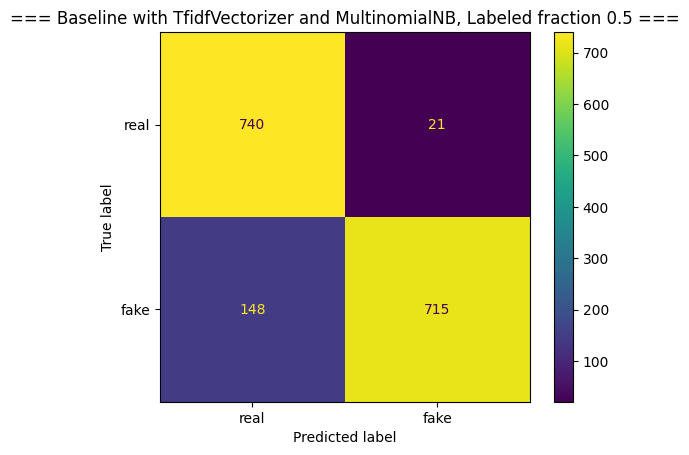

ROC-AUC: 0.9660
PR-AUC: 0.9733


=== Computing TF-IDF ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=2363, R_N=2363, leftover=1666
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/30 - Loss: 0.6377
Epoch 20/30 - Loss: 0.5537
Epoch 30/30 - Loss: 0.4847
=== Evaluation on test set ===


=== Keywords attention PU-LP with TFIDF, Labeled fraction 0.5 ===
              precision    recall  f1-score   support

        real     0.6903    0.7792    0.7321       761
        fake     0.7804    0.6918    0.7334       863

    accuracy                         0.7328      1624
   macro avg     0.7354    0.7355    0.7328      1624
weighted avg     0.7382    0.7328    0.7328      1624



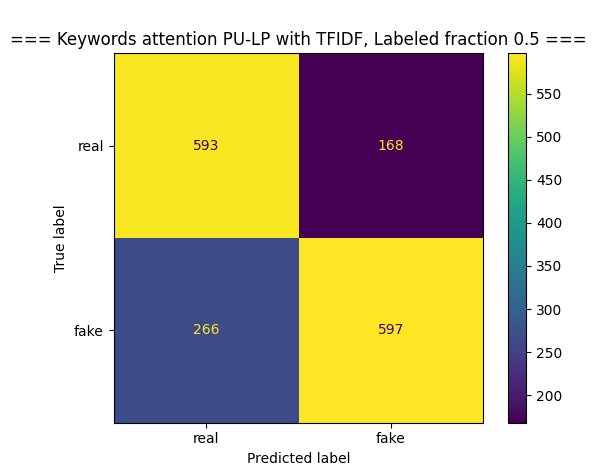



=== Training Doc2Vec ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=2363, R_N=2363, leftover=1666
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/50 - Loss: 0.6081
Epoch 20/50 - Loss: 0.5790
Epoch 30/50 - Loss: 0.5564
Epoch 40/50 - Loss: 0.5298
Epoch 50/50 - Loss: 0.5135
=== Evaluation on test set ===


=== Keywords attention PU-LP with Doc2Vec, Labeled fraction 0.5 ===
              precision    recall  f1-score   support

        real     0.8508    0.9067    0.8779       761
        fake     0.9127    0.8598    0.8854       863

    accuracy                         0.8818      1624
   macro avg     0.8817    0.8832    0.8817      1624
weighted avg     0.8837    0.8818    0.8819      1624



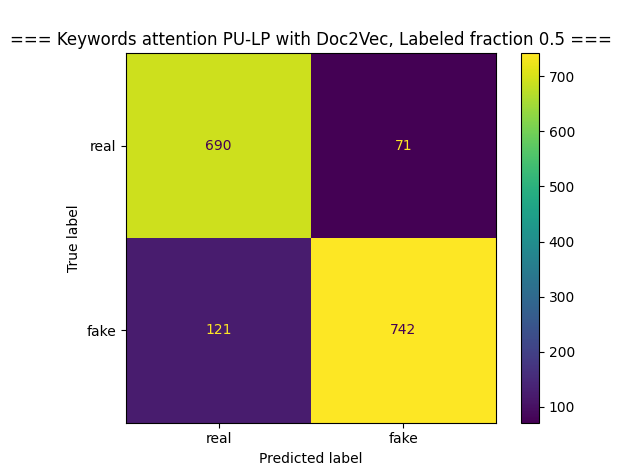




=== Baseline with TfidfVectorizer and MultinomialNB, Labeled fraction 0.4 ===
              precision    recall  f1-score   support

        real     0.8133    0.9790    0.8885       761
        fake     0.9774    0.8019    0.8810       863

    accuracy                         0.8849      1624
   macro avg     0.8954    0.8904    0.8847      1624
weighted avg     0.9005    0.8849    0.8845      1624



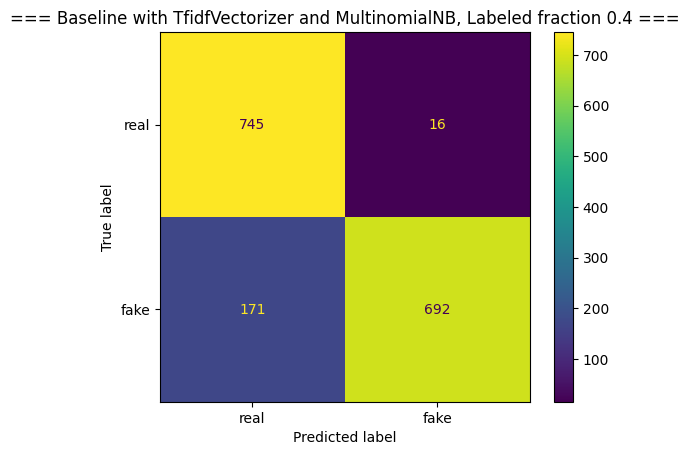

ROC-AUC: 0.9626
PR-AUC: 0.9707


=== Computing TF-IDF ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=1890, R_N=1890, leftover=2957
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/30 - Loss: 0.6247
Epoch 20/30 - Loss: 0.5378
Epoch 30/30 - Loss: 0.4709
=== Evaluation on test set ===


=== Keywords attention PU-LP with TFIDF, Labeled fraction 0.4 ===
              precision    recall  f1-score   support

        real     0.7519    0.8003    0.7753       761
        fake     0.8133    0.7671    0.7895       863

    accuracy                         0.7826      1624
   macro avg     0.7826    0.7837    0.7824      1624
weighted avg     0.7845    0.7826    0.7828      1624



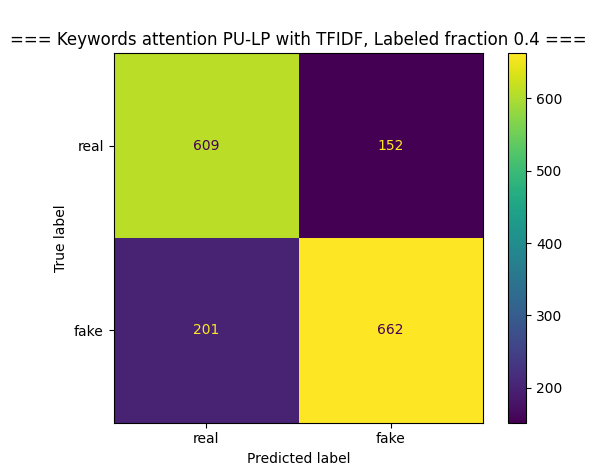



=== Training Doc2Vec ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=1890, R_N=1890, leftover=2957
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/50 - Loss: 0.5862
Epoch 20/50 - Loss: 0.5454
Epoch 30/50 - Loss: 0.5228
Epoch 40/50 - Loss: 0.5032
Epoch 50/50 - Loss: 0.4934
=== Evaluation on test set ===


=== Keywords attention PU-LP with Doc2Vec, Labeled fraction 0.4 ===
              precision    recall  f1-score   support

        real     0.8676    0.9041    0.8855       761
        fake     0.9122    0.8783    0.8949       863

    accuracy                         0.8904      1624
   macro avg     0.8899    0.8912    0.8902      1624
weighted avg     0.8913    0.8904    0.8905      1624



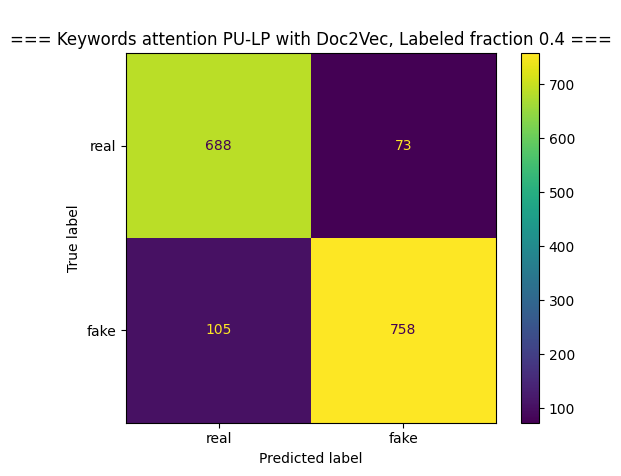




=== Baseline with TfidfVectorizer and MultinomialNB, Labeled fraction 0.3 ===
              precision    recall  f1-score   support

        real     0.7862    0.9855    0.8746       761
        fake     0.9836    0.7636    0.8598       863

    accuracy                         0.8676      1624
   macro avg     0.8849    0.8746    0.8672      1624
weighted avg     0.8911    0.8676    0.8667      1624



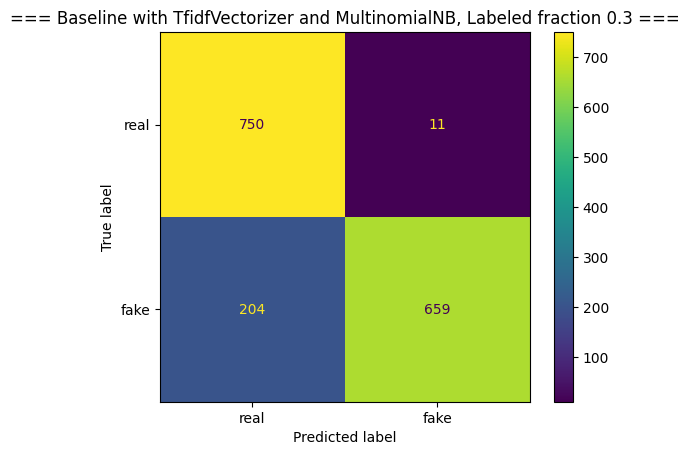

ROC-AUC: 0.9619
PR-AUC: 0.9704


=== Computing TF-IDF ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=1418, R_N=1418, leftover=4246
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/30 - Loss: 0.6188
Epoch 20/30 - Loss: 0.5152
Epoch 30/30 - Loss: 0.4369
=== Evaluation on test set ===


=== Keywords attention PU-LP with TFIDF, Labeled fraction 0.3 ===
              precision    recall  f1-score   support

        real     0.7295    0.7582    0.7436       761
        fake     0.7791    0.7520    0.7653       863

    accuracy                         0.7549      1624
   macro avg     0.7543    0.7551    0.7544      1624
weighted avg     0.7558    0.7549    0.7551      1624



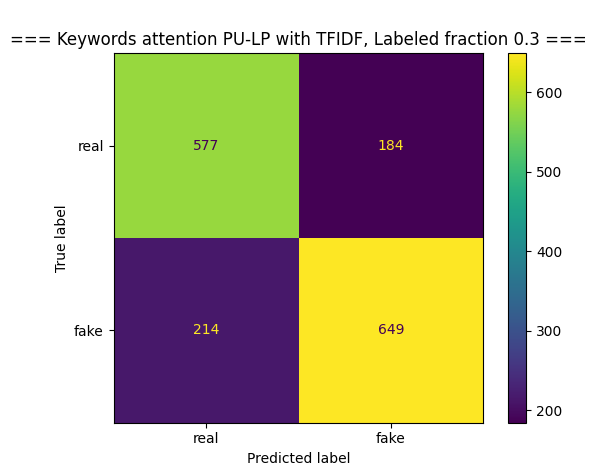



=== Training Doc2Vec ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=1418, R_N=1418, leftover=4246
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/50 - Loss: 0.5713
Epoch 20/50 - Loss: 0.5351
Epoch 30/50 - Loss: 0.5107
Epoch 40/50 - Loss: 0.4932
Epoch 50/50 - Loss: 0.4804
=== Evaluation on test set ===


=== Keywords attention PU-LP with Doc2Vec, Labeled fraction 0.3 ===
              precision    recall  f1-score   support

        real     0.9128    0.9212    0.9169       761
        fake     0.9299    0.9224    0.9261       863

    accuracy                         0.9218      1624
   macro avg     0.9213    0.9218    0.9215      1624
weighted avg     0.9219    0.9218    0.9218      1624



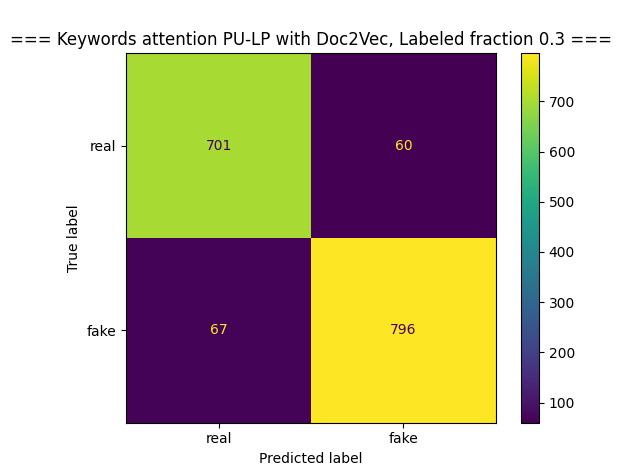




=== Baseline with TfidfVectorizer and MultinomialNB, Labeled fraction 0.2 ===
              precision    recall  f1-score   support

        real     0.6915    0.9895    0.8141       761
        fake     0.9850    0.6107    0.7539       863

    accuracy                         0.7882      1624
   macro avg     0.8383    0.8001    0.7840      1624
weighted avg     0.8475    0.7882    0.7821      1624



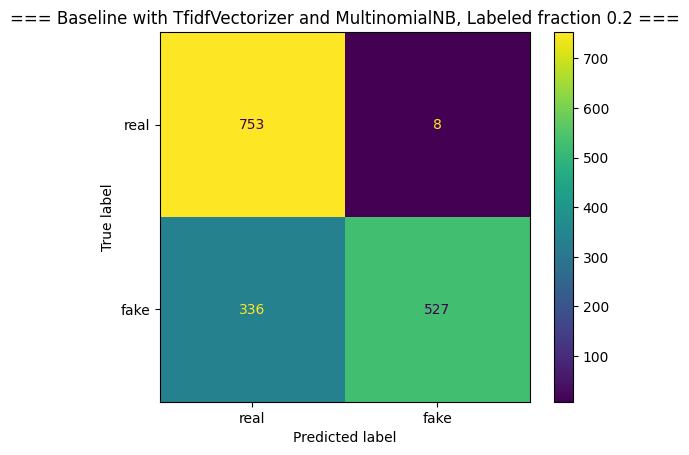

ROC-AUC: 0.9443
PR-AUC: 0.9581


=== Computing TF-IDF ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=944, R_N=944, leftover=5539
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/30 - Loss: 0.6161
Epoch 20/30 - Loss: 0.5084
Epoch 30/30 - Loss: 0.4358
=== Evaluation on test set ===


=== Keywords attention PU-LP with TFIDF, Labeled fraction 0.2 ===
              precision    recall  f1-score   support

        real     0.7853    0.7162    0.7491       761
        fake     0.7677    0.8273    0.7964       863

    accuracy                         0.7752      1624
   macro avg     0.7765    0.7718    0.7728      1624
weighted avg     0.7760    0.7752    0.7743      1624



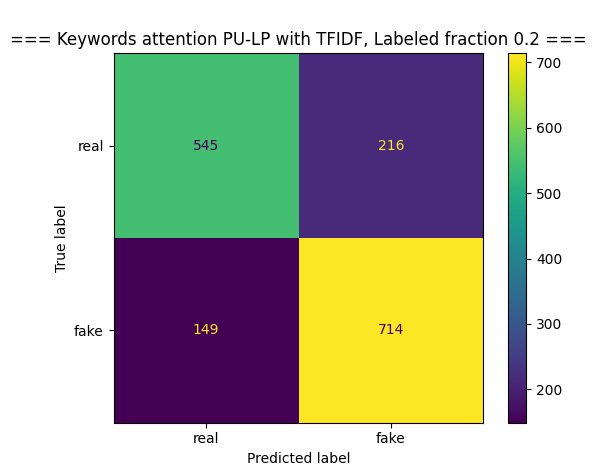



=== Training Doc2Vec ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=944, R_N=944, leftover=5539
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/50 - Loss: 0.5821
Epoch 20/50 - Loss: 0.5393
Epoch 30/50 - Loss: 0.5207
Epoch 40/50 - Loss: 0.5069
Epoch 50/50 - Loss: 0.4974
=== Evaluation on test set ===


=== Keywords attention PU-LP with Doc2Vec, Labeled fraction 0.2 ===
              precision    recall  f1-score   support

        real     0.9128    0.8804    0.8963       761
        fake     0.8978    0.9258    0.9116       863

    accuracy                         0.9046      1624
   macro avg     0.9053    0.9031    0.9040      1624
weighted avg     0.9048    0.9046    0.9044      1624



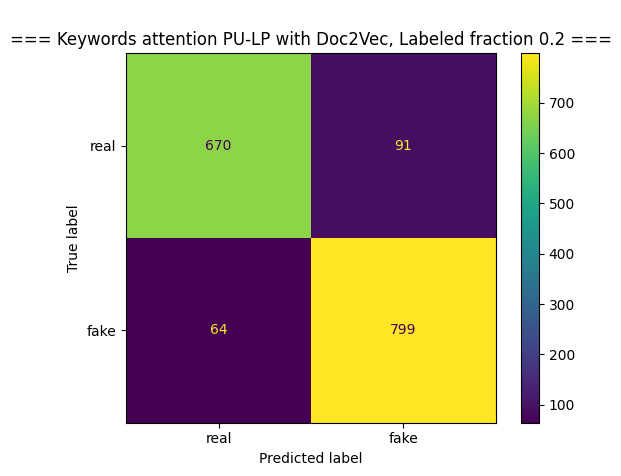




=== Baseline with TfidfVectorizer and MultinomialNB, Labeled fraction 0.1 ===
              precision    recall  f1-score   support

        real     0.5125    0.9961    0.6768       761
        fake     0.9793    0.1645    0.2817       863

    accuracy                         0.5542      1624
   macro avg     0.7459    0.5803    0.4793      1624
weighted avg     0.7606    0.5542    0.4669      1624



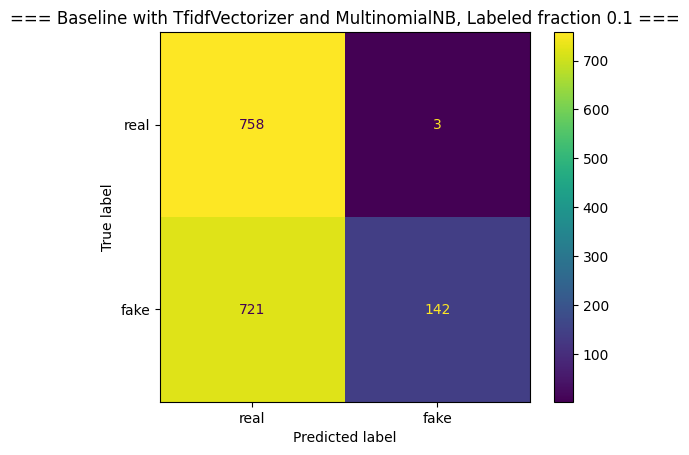

ROC-AUC: 0.8920
PR-AUC: 0.9038


=== Computing TF-IDF ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=472, R_N=472, leftover=6828
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/30 - Loss: 0.6044
Epoch 20/30 - Loss: 0.5272
Epoch 30/30 - Loss: 0.4304
=== Evaluation on test set ===


=== Keywords attention PU-LP with TFIDF, Labeled fraction 0.1 ===
              precision    recall  f1-score   support

        real     0.8716    0.2497    0.3882       761
        fake     0.5939    0.9676    0.7360       863

    accuracy                         0.6312      1624
   macro avg     0.7327    0.6086    0.5621      1624
weighted avg     0.7240    0.6312    0.5730      1624



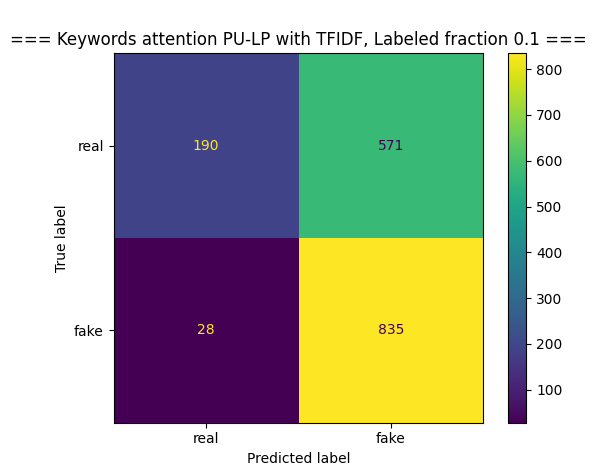



=== Training Doc2Vec ===
=== Building doc-doc graph ===
=== Computing Katz matrix ===
=== Iterative PU Label Propagation ===
  => Found R_I=472, R_N=472, leftover=6828
=== Building doc-term edges ===
=== Converting Nx -> HeteroData ===
=== Filling doc embeddings ===
=== Building Multi-Layer HeteroGAT model ===
=== Training ===
Epoch 10/50 - Loss: 0.6037
Epoch 20/50 - Loss: 0.5617
Epoch 30/50 - Loss: 0.5259
Epoch 40/50 - Loss: 0.5080
Epoch 50/50 - Loss: 0.5007
=== Evaluation on test set ===


=== Keywords attention PU-LP with Doc2Vec, Labeled fraction 0.1 ===
              precision    recall  f1-score   support

        real     0.9482    0.6978    0.8039       761
        fake     0.7838    0.9664    0.8656       863

    accuracy                         0.8405      1624
   macro avg     0.8660    0.8321    0.8348      1624
weighted avg     0.8609    0.8405    0.8367      1624



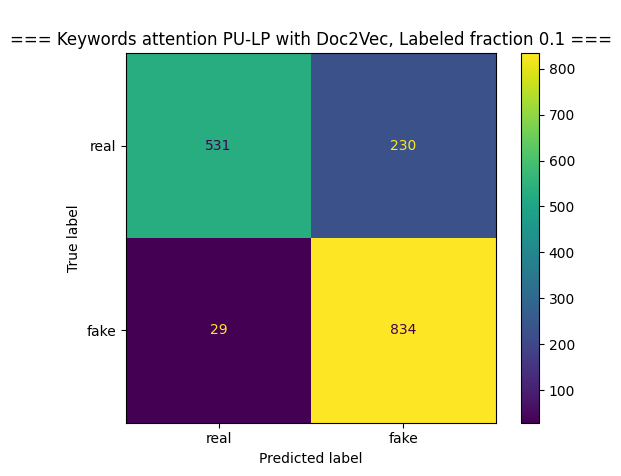

In [ ]:
dataset_file = "data/processed_eval.csv"
fraction = [0.5, 0.4, 0.3, 0.2, 0.1]


for fraction in fraction:
    data = KAFNData(
        csv_path=dataset_file, random_state=42, fraction_fake_labeled=fraction, test_size=0.2
    )
    test_baseline(data)
    test_pulp_tfidfvectorizer_pipeline(data)
    test_pulp_doc2vec_pipeline(data)